Purpose: Re-make HybridExpress figures with new physiology classifications from titratable acidity data.<br>
Author: Anna Pardo<br>
Date initiated: Apr. 20, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# load results dataframe
res = pd.read_csv("./hybexp_top30pct_partitiongenes_bygttreat.txt",sep="\t",header="infer")
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [3]:
# split genotype & treatment info
gtt = res["genotype_treat"].str.split("_",expand=True)
gtt.rename(columns={0:"genotype",1:"treat"},inplace=True)
res = pd.concat([res,gtt],axis=1)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,18,D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D,18,D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D,18,D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D,18,D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D,18,D


In [4]:
physcat = json.load(open("../../physiology/physiological_categories_from_TA.json"))

In [5]:
res["phys"] = res["genotype"].map(physcat)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,18,D,C3+CAM
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D,18,D,C3+CAM
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D,18,D,C3+CAM
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D,18,D,C3+CAM
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D,18,D,C3+CAM


In [6]:
len(res["Gene"].unique())

26669

## Make summary barplot figures

In [7]:
classcounts = res.groupby(["phys","genotype","treat","Class"]).count().reset_index()[["phys","genotype","treat","Class","Gene"]]
classcounts.head()

,phys,genotype,treat,Class,Gene
0,C3+CAM,18,D,ADD,5654
1,C3+CAM,18,D,DOWN,3794
2,C3+CAM,18,D,ELD_P1,5026
3,C3+CAM,18,D,ELD_P2,3975
4,C3+CAM,18,D,UP,3576


In [8]:
def subcounts(cdf,colname,colval):
    subdf = cdf[cdf[colname]==colval]
    return subdf.sort_values(by=["treat","phys"],ascending=False)

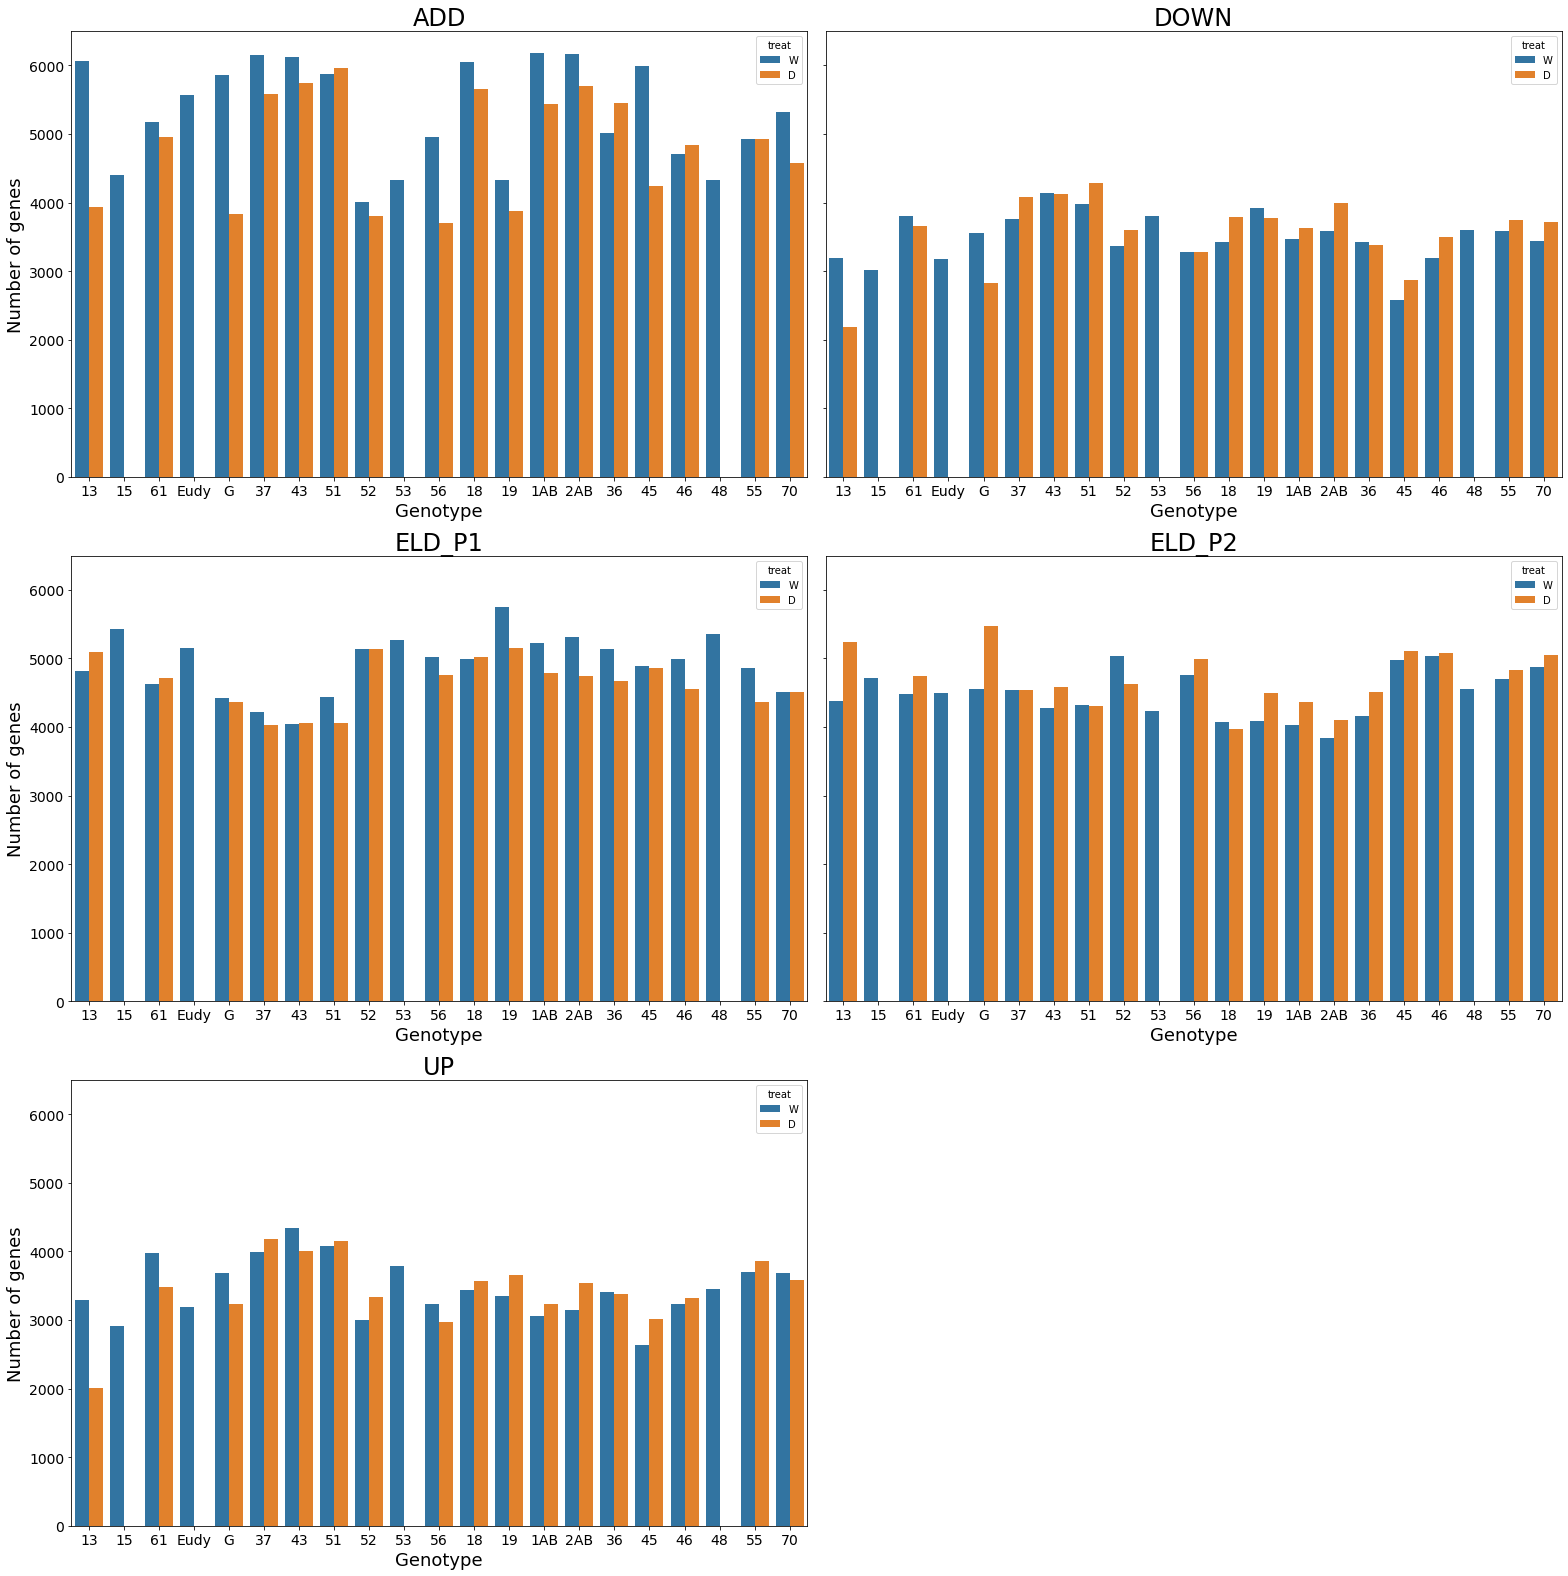

In [9]:
fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(22,22),sharey=True)
r=0
c=0
for i in classcounts["Class"].unique():
    df = subcounts(classcounts,"Class",i)
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="Gene",hue="treat")
    ax[r,c].set_title(i,fontsize=24)
    ax[r,c].tick_params(which="both",labelsize=14)
    ax[r,c].set_xlabel("Genotype",fontsize=18)
    if c==0:
        ax[r,c].set_ylabel("Number of genes",fontsize=18)
    else:
        ax[r,c].set_ylabel("")
    
    if c<1:
        c+=1
    else:
        c=0
        r+=1
        
fig.tight_layout()
fig.delaxes(ax[2,1])

plt.savefig("./top30pct_figures/top30_ngenes_gttreat_class.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_ngenes_gttreat_class.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_ngenes_gttreat_class.svg",dpi=200,bbox_inches="tight")

In [11]:
classcounts.sort_values(by=["treat","Class"],ascending=False,inplace=True)

In [12]:
classcounts["phys"].unique()

array(['C3+CAM', 'CAM', 'facultative CAM'], dtype=object)

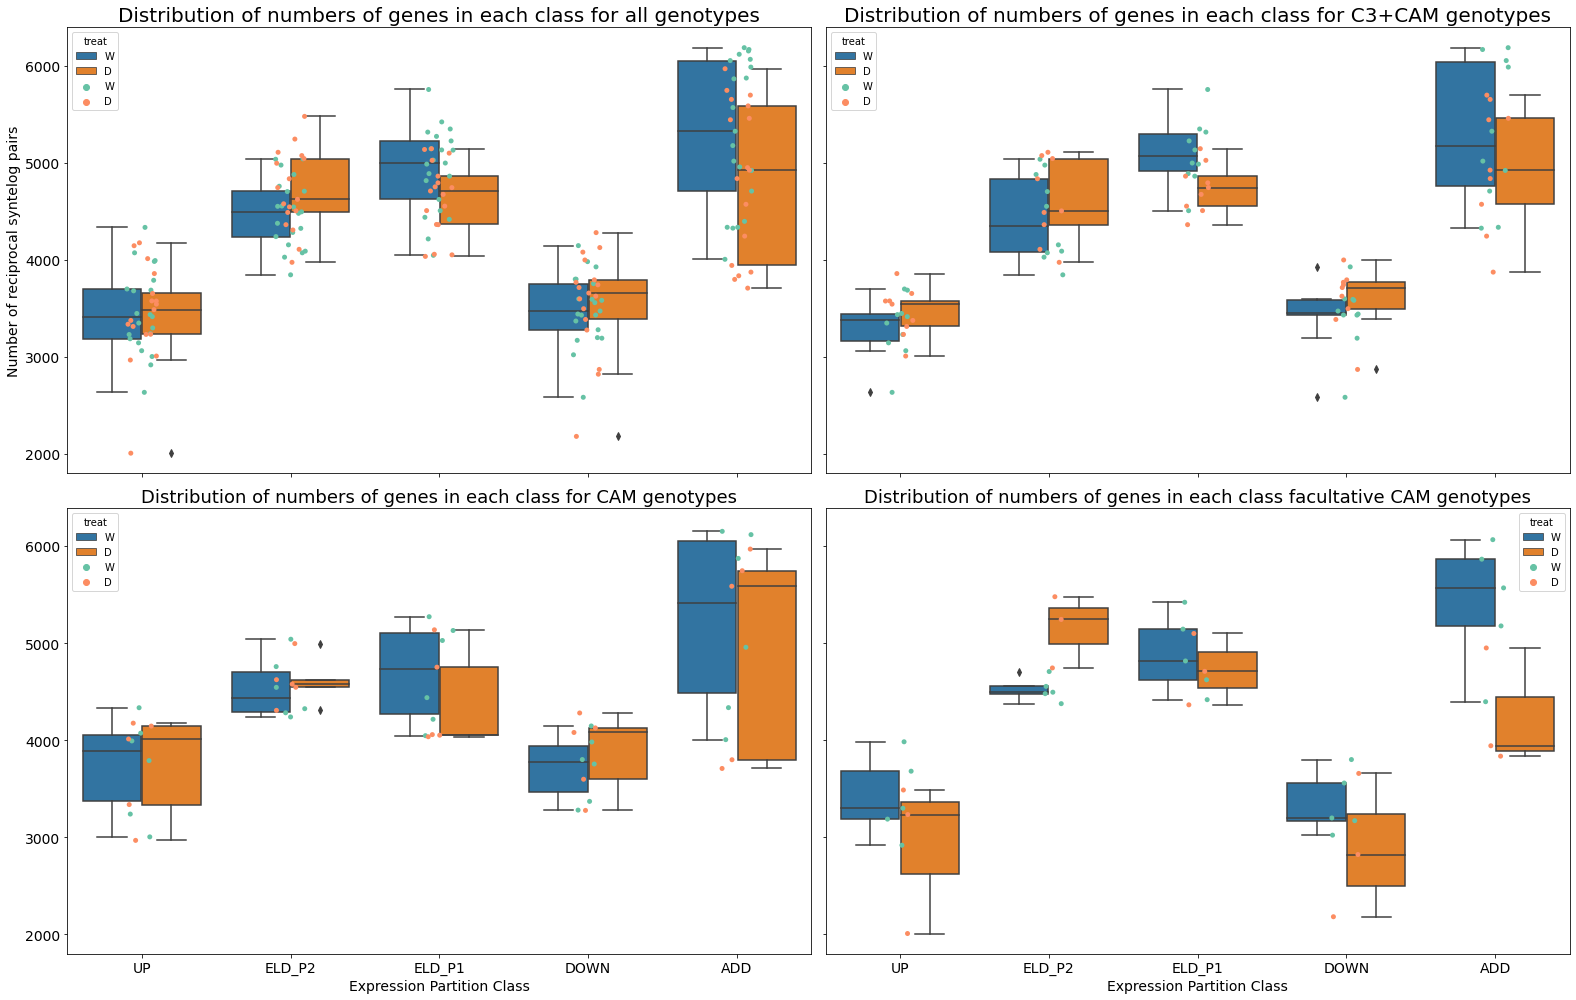

In [13]:
# make a boxplot: distribution of genotypes' numbers of genes per class (by treatment) with data points
# four of these: one with all genotypes, one with just genotypes from each physiological category
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(22,14),sharex=True,sharey=True)

sns.boxplot(ax=ax[0,0],data=classcounts,x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[0,0],data=classcounts,x="Class",y="Gene",hue="treat",palette="Set2")
ax[0,0].set_title("Distribution of numbers of genes in each class for all genotypes",fontsize=20)
ax[0,0].tick_params(which="both",labelsize=14)
ax[0,0].set_ylabel("Number of reciprocal syntelog pairs",fontsize=14)
ax[0,0].set_xlabel("")

sns.boxplot(ax=ax[0,1],data=classcounts[classcounts["phys"]=="C3+CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[0,1],data=classcounts[classcounts["phys"]=="C3+CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[0,1].set_title("Distribution of numbers of genes in each class for C3+CAM genotypes",fontsize=20)
ax[0,1].set_ylabel("")
ax[0,1].set_xlabel("")

sns.boxplot(ax=ax[1,1],data=classcounts[classcounts["phys"]=="facultative CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[1,1],data=classcounts[classcounts["phys"]=="facultative CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[1,1].set_title("Distribution of numbers of genes in each class facultative CAM genotypes",fontsize=18)
ax[1,1].set_ylabel("")
ax[1,1].set_xlabel("Expression Partition Class",fontsize=14)
ax[1,1].tick_params(which="both",labelsize=14)

sns.boxplot(ax=ax[1,0],data=classcounts[classcounts["phys"]=="CAM"],x="Class",y="Gene",hue="treat")
sns.stripplot(ax=ax[1,0],data=classcounts[classcounts["phys"]=="CAM"],x="Class",y="Gene",hue="treat",palette="Set2")
ax[1,0].set_title("Distribution of numbers of genes in each class for CAM genotypes",fontsize=18)
ax[1,0].set_ylabel("")
ax[1,0].set_xlabel("Expression Partition Class",fontsize=14)
ax[1,0].tick_params(which="both",labelsize=14)

fig.tight_layout()

plt.savefig("./top30pct_figures/top30_boxplots_ngenes_byclass.png",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_boxplots_ngenes_byclass.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_boxplots_ngenes_byclass.svg",dpi=200,bbox_inches="tight")

In [15]:
classcounts.to_csv("./hybexp_classcounts.txt",sep="\t",header=True,index=False)

In [17]:
## add treat_phys to the count data
classcounts["treat_phys"] = classcounts["phys"]+"_"+classcounts["treat"]
classcounts.head()

,phys,genotype,treat,Class,Gene,treat_phys
9,C3+CAM,18,W,UP,3436,C3+CAM_W
19,C3+CAM,19,W,UP,3349,C3+CAM_W
29,C3+CAM,1AB,W,UP,3064,C3+CAM_W
39,C3+CAM,2AB,W,UP,3145,C3+CAM_W
49,C3+CAM,36,W,UP,3415,C3+CAM_W


In [18]:
custompal = {
    "C3+CAM_W":"skyblue",
    "CAM_W":"navy",
    "facultative CAM_W":"royalblue",
    "C3+CAM_D":"coral",
    "CAM_D":"saddlebrown",
    "facultative CAM_D":"orangered"
}

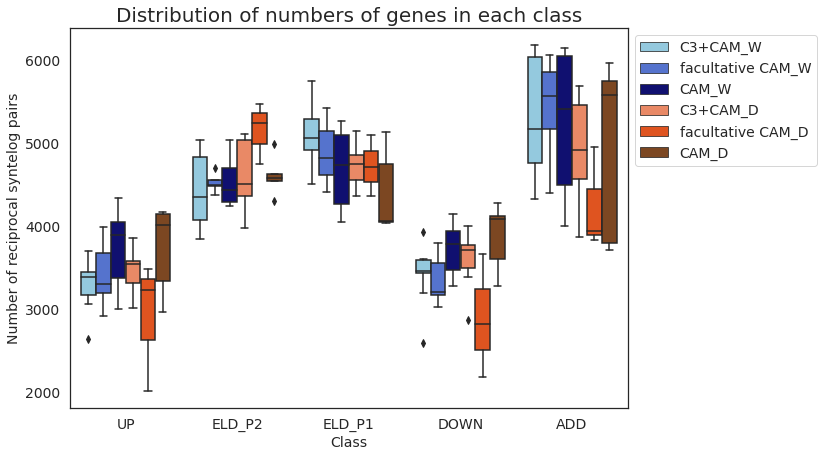

In [20]:
sns.set_theme(style="white")
fig,ax = plt.subplots(figsize=(10,7))

sns.boxplot(data=classcounts,x="Class",y="Gene",hue="treat_phys",palette=custompal,
           hue_order=["C3+CAM_W","facultative CAM_W","CAM_W","C3+CAM_D","facultative CAM_D","CAM_D"])
#sns.stripplot(data=classcounts,x="Class",y="Gene",hue="treat",palette="Set2")
ax.set_title("Distribution of numbers of genes in each class",fontsize=20)
ax.tick_params(which="both",labelsize=14)
ax.set_ylabel("Number of reciprocal syntelog pairs",fontsize=14)
ax.set_xlabel("Class",fontsize=14)
plt.legend(fontsize=14,bbox_to_anchor=(1,1))

plt.savefig("./top30pct_figures/top30_singlebox_byphystreat.png",dpi=300,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_singlebox_byphystreat.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./top30pct_figures/top30_singlebox_byphystreat.svg",dpi=300,bbox_inches="tight")

In [21]:
# find mean numbers of genes in each class overall & for each physiological set
cmeans = classcounts.groupby(["treat","Class"]).mean().reset_index()
cmeans["phys"] = "all"
cmeans.head()

,treat,Class,Gene,phys
0,D,ADD,4838.352941,all
1,D,DOWN,3554.352941,all
2,D,ELD_P1,4640.352941,all
3,D,ELD_P2,4707.411765,all
4,D,UP,3441.764706,all


In [22]:
cmeans2 = classcounts.groupby(["phys","treat","Class"]).mean().reset_index()
cmeans2.head()

,phys,treat,Class,Gene
0,C3+CAM,D,ADD,4967.777778
1,C3+CAM,D,DOWN,3600.000000
2,C3+CAM,D,ELD_P1,4741.555556
3,C3+CAM,D,ELD_P2,4611.666667
4,C3+CAM,D,UP,3460.111111


In [23]:
cmeans = pd.concat([cmeans[["phys","treat","Class","Gene"]],cmeans2])
cmeans = cmeans.round()
cmeans["Gene"] = cmeans["Gene"].astype(int)
cmeans.head()

,phys,treat,Class,Gene
0,all,D,ADD,4838
1,all,D,DOWN,3554
2,all,D,ELD_P1,4640
3,all,D,ELD_P2,4707
4,all,D,UP,3442


In [24]:
cmeans.rename(columns={"phys":"Gene Set","Gene":"Mean Number of Syntelogs","treat":"Treatment"},inplace=True)

In [25]:
cmeans.to_csv("./mean_genenumbers_hybexpclass_acrossgt.csv",sep=",",header=True,index=False)

In [27]:
cmeans.sort_values(by="Mean Number of Syntelogs",ascending=False)

,Gene Set,Treatment,Class,Mean Number of Syntelogs
25,facultative CAM,W,ADD,5416
5,all,W,ADD,5312
5,C3+CAM,W,ADD,5303
15,CAM,W,ADD,5241
23,facultative CAM,D,ELD_P2,5156
7,C3+CAM,W,ELD_P1,5102
0,C3+CAM,D,ADD,4968
10,CAM,D,ADD,4962
7,all,W,ELD_P1,4933
27,facultative CAM,W,ELD_P1,4885


## Find & visualize CAM genes in HybridExpress results

In [28]:
## load CAM annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [29]:
# load synteny information
syn = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",header="infer")
syn.head()

,GeneID,syntelogID
0,YufilH1000002m.g,recip_syn1
1,Yucal.01G000100.v2.1,recip_syn1
2,YufilH1000007m.g,recip_syn2
3,Yucal.01G000200.v2.1,recip_syn2
4,YufilH1000011m.g,recip_syn3


In [30]:
camsyn = cam.merge(syn)
camsyn.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,recip_syn3628
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,recip_syn7619
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya,recip_syn13926
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya,recip_syn6335


In [31]:
# merge with res
camres = camsyn.merge(res.rename(columns={"Gene":"syntelogID"}))
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.012556,1.361738,18_D,18,D,C3+CAM
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.452933,0.797308,2AB_D,2AB,D,C3+CAM
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.998544,1.344955,1AB_D,1AB,D,C3+CAM
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,6,UP,0.755518,1.112692,19_D,19,D,C3+CAM
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.329355,1.680807,G_D,G,D,facultative CAM


In [42]:
# load syntelog names
import json
synnames = json.load(open("../rename_CAM_syntelogs.json"))

In [43]:
camres["synname"] = camres["syntelogID"].map(synnames)

In [44]:
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys,synname
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.012556,1.361738,18_D,18,D,C3+CAM,bCA1234_1/2
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.452933,0.797308,2AB_D,2AB,D,C3+CAM,bCA1234_1/2
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.998544,1.344955,1AB_D,1AB,D,C3+CAM,bCA1234_1/2
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,6,UP,0.755518,1.112692,19_D,19,D,C3+CAM,bCA1234_1/2
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.329355,1.680807,G_D,G,D,facultative CAM,bCA1234_1/2


In [45]:
# subset to a single subgenome to avoid duplicates
camres = camres[camres["subgenome"]=="Ya"]

In [46]:
cam_class_sum = camres.groupby(["synname","Class","phys","treat"]).count().reset_index()[["synname",
                                                                                                   "Class","treat",
                                                                                                   "phys","genotype"]]
cam_class_sum.head()

,synname,Class,treat,phys,genotype
0,BPPC_1,ADD,W,C3+CAM,1
1,BPPC_1,DOWN,D,C3+CAM,1
2,BPPC_1,DOWN,W,C3+CAM,4
3,BPPC_1,DOWN,D,CAM,1
4,BPPC_1,DOWN,W,CAM,2


In [47]:
cam_class_sum["phystreat"] = cam_class_sum["phys"]+"_"+cam_class_sum["treat"]

In [48]:
cam_class_sum["phystreat"].unique()

array(['C3+CAM_W', 'C3+CAM_D', 'CAM_D', 'CAM_W', 'facultative CAM_D',
       'facultative CAM_W'], dtype=object)

In [55]:
# convert to wide - write a function for this
def to_wide_data(c,data=cam_class_sum):
    sub = data[data["Class"]==c]
    wide = pd.pivot(sub,index=["synname"],columns="phystreat",values="genotype")
    wide.fillna(0,inplace=True)
    return wide

In [50]:
custompal = {
    "C3+CAM_W":"skyblue",
    "facultative CAM_W":"royalblue",
    "CAM_W":"navy",
    "C3+CAM_D":"coral",
    "facultative CAM_D":"orangered",
    "CAM_D":"saddlebrown"
}

In [53]:
cmap = LinearSegmentedColormap.from_list("custom",list(custompal.values()))

In [56]:
add = to_wide_data("ADD")
eld1 = to_wide_data("ELD_P1")
eld2 = to_wide_data("ELD_P2")
up = to_wide_data("UP")
down = to_wide_data("DOWN")

In [57]:
# get out a list of all the genes
all_genes = sorted(set().union(
    add.index,
    eld1.index,
    eld2.index,
    up.index,
    down.index
))

In [58]:
def plot_subplot(data,c,axc,axs=ax):
    # ensure all genes are present
    data = data.reindex(all_genes, fill_value=0)
    # reorder columns of data according to custompal order
    data = data[list(custompal.keys())]
    # reorder data by index (gene family)
    data = data.sort_index(axis=0,ascending=True)
    
    data.plot(kind="barh",ax=axs[axc],stacked=True,colormap=cmap)
    axs[axc].set_title(c,fontsize=28)
    axs[axc].tick_params(which="both",labelsize=20)
    axs[axc].set_ylabel("")
    axs[axc].set_xticks(ticks=range(0,41,5))
    axs[axc].legend(labels=["C3 W","possibly facultative CAM W","facultative CAM W",
                       "C3 D","possibly facultative CAM D","facultative CAM D"],fontsize=16)

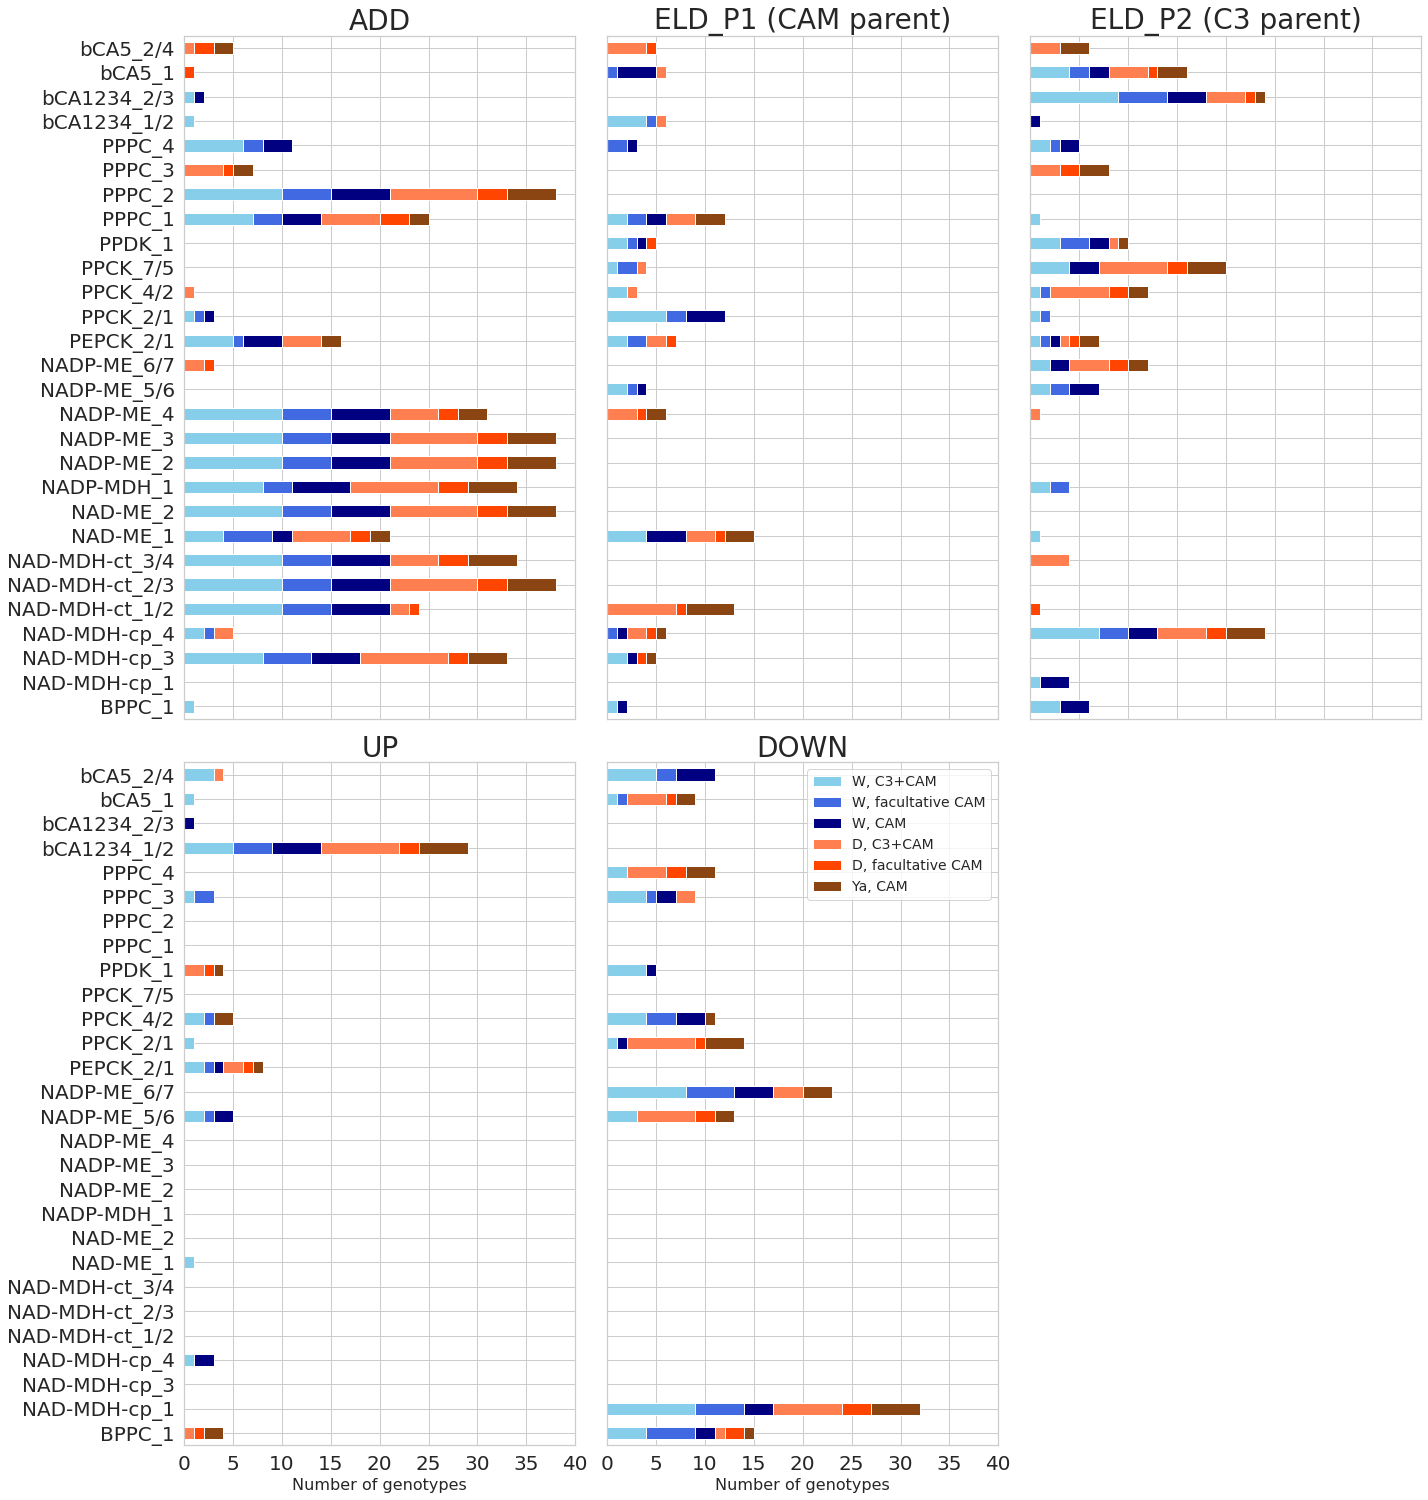

In [62]:
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,21),sharex=True,sharey=True)

plot_subplot(add,"ADD",(0,0),ax)
ax[0,0].get_legend().remove()
plot_subplot(eld1,"ELD_P1 (CAM parent)",(0,1),ax)
ax[0,1].get_legend().remove()
plot_subplot(eld2,"ELD_P2 (C3 parent)",(0,2),ax)
ax[0,2].get_legend().remove()
plot_subplot(up,"UP",(1,0),ax)
ax[1,0].get_legend().remove()
plot_subplot(down,"DOWN",(1,1),ax)
ax[1,1].legend(bbox_to_anchor=(1,1),labels=["W, C3+CAM","W, facultative CAM","W, CAM",
                                       "D, C3+CAM","D, facultative CAM","Ya, CAM"],
          fontsize=14)

ax[1,0].set_xlabel("Number of genotypes",fontsize=16)
ax[1,1].set_xlabel("Number of genotypes",fontsize=16)

fig.delaxes(ax[1,2])
fig.tight_layout()

plt.savefig("./hybexp_campartitions_byphys_top30_forpaper.png",dpi=200,bbox_inches="tight")
plt.savefig("./hybexp_campartitions_byphys_top30_forpaper.svg",dpi=200,bbox_inches="tight")
plt.savefig("./hybexp_campartitions_byphys_top30_forpaper.pdf",dpi=200,bbox_inches="tight")

In [63]:
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys,synname
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.012556,1.361738,18_D,18,D,C3+CAM,bCA1234_1/2
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.452933,0.797308,2AB_D,2AB,D,C3+CAM,bCA1234_1/2
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.998544,1.344955,1AB_D,1AB,D,C3+CAM,bCA1234_1/2
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,6,UP,0.755518,1.112692,19_D,19,D,C3+CAM,bCA1234_1/2
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.329355,1.680807,G_D,G,D,facultative CAM,bCA1234_1/2


In [66]:
cr = camres[["synname","syntelogID","phys","genotype","treat","genotype_treat","Category","Class"]]

In [67]:
# save this
cr.to_csv("./camgenes_in_hybexp_results_withphys.txt",sep="\t",header=True,index=False)